# Imports and Loading Data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_data.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900.0


Explanation: We import seaborn and matplotlib for high-quality visualizations and load the featured dataset prepared in the previous phase.

# (Creating Missing Features)

In [ ]:
df['House Age'] = df['Yr Sold'] - df['Year Built']
bins = [0, 10, 40, 200]
labels = ['New', 'Recent', 'Old']
df['Age Group'] = pd.cut(df['House Age'], bins=bins, labels=labels)

Explanation: Before starting the analysis, we ensure all calculated features like 'House Age' and 'Age Group' are present in the DataFrame to avoid errors during plotting.

# (Histograms & KDE)

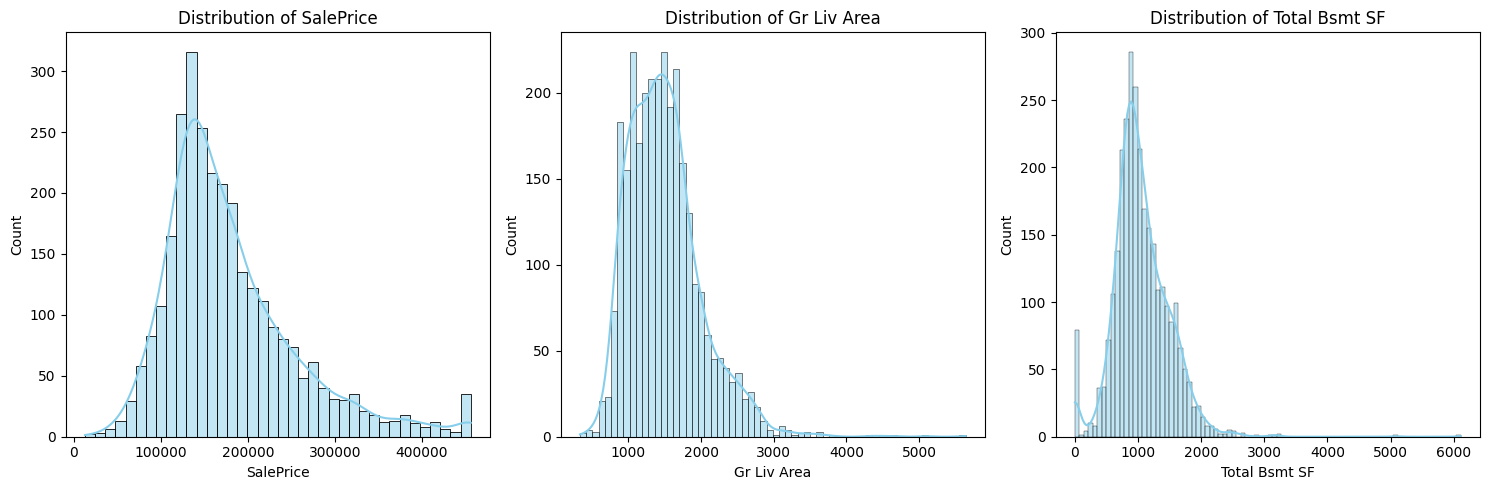

In [ ]:
features = ['SalePrice', 'Gr Liv Area', 'Total Bsmt SF']
plt.figure(figsize=(15, 5))

for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

Insight: These histograms show the spread of our key numerical variables. After transformation, the distributions appear more symmetric, which is ideal for statistical modeling.

# (Grouped Boxplots)

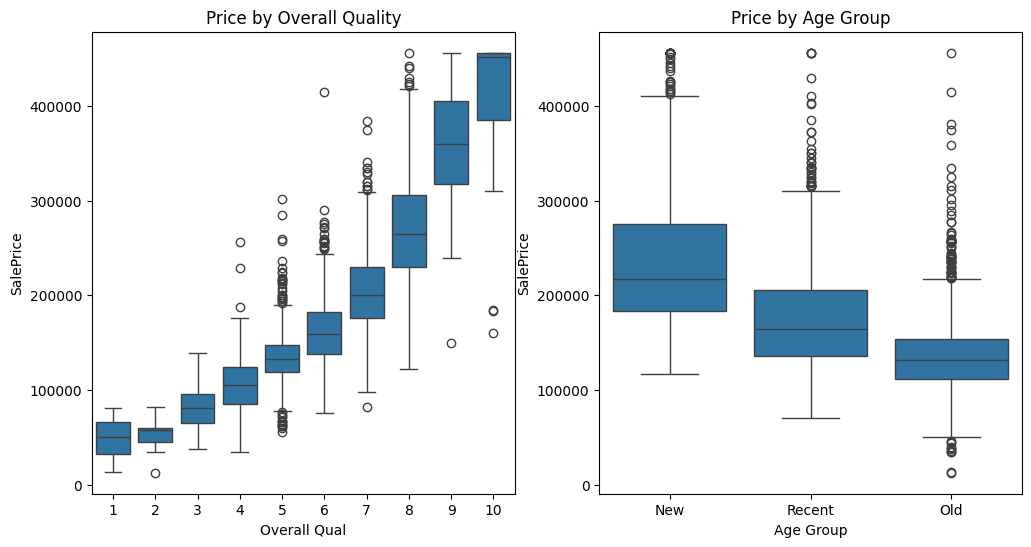

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='Overall Qual', y='SalePrice', data=df)
plt.title('Price by Overall Quality')

plt.subplot(1, 2, 2)
sns.boxplot(x='Age Group', y='SalePrice', data=df)
plt.title('Price by Age Group')

plt.show()

Insight: The boxplots reveal a strong correlation between quality/age and price. Higher quality and newer houses clearly command a premium in the market.

# (Correlation Heatmap)

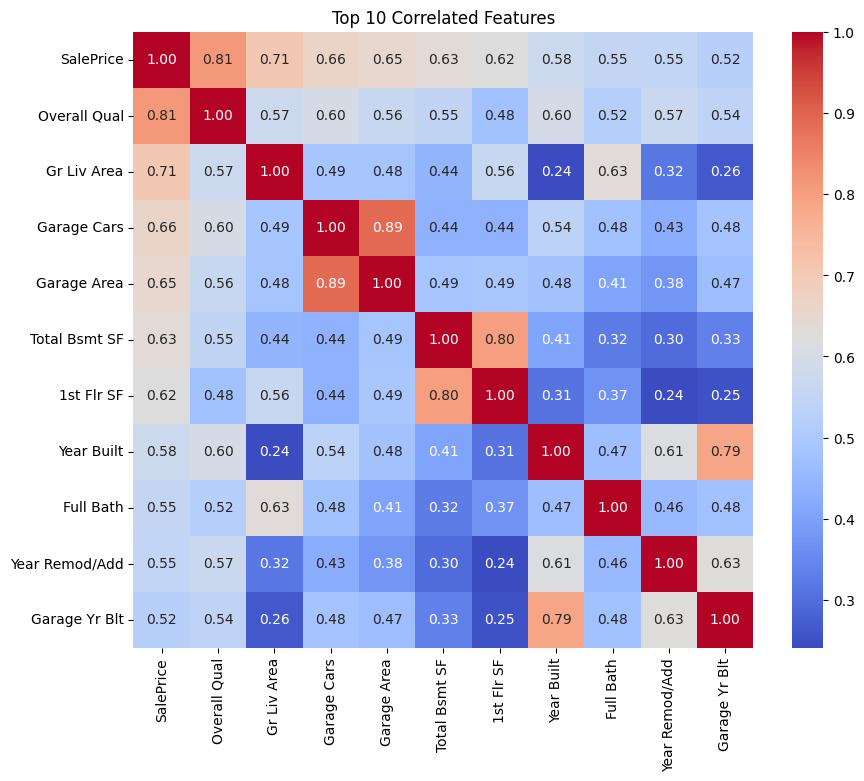

In [ ]:
plt.figure(figsize=(10, 8))
top_10_corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(11)
sns.heatmap(df[top_10_corr.index].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Top 10 Correlated Features')
plt.show()

Insight: This heatmap highlights the most influential features. 'Overall Qual' and 'Gr Liv Area' have the strongest positive impact on the 'SalePrice'.

# (Scatter Plot)

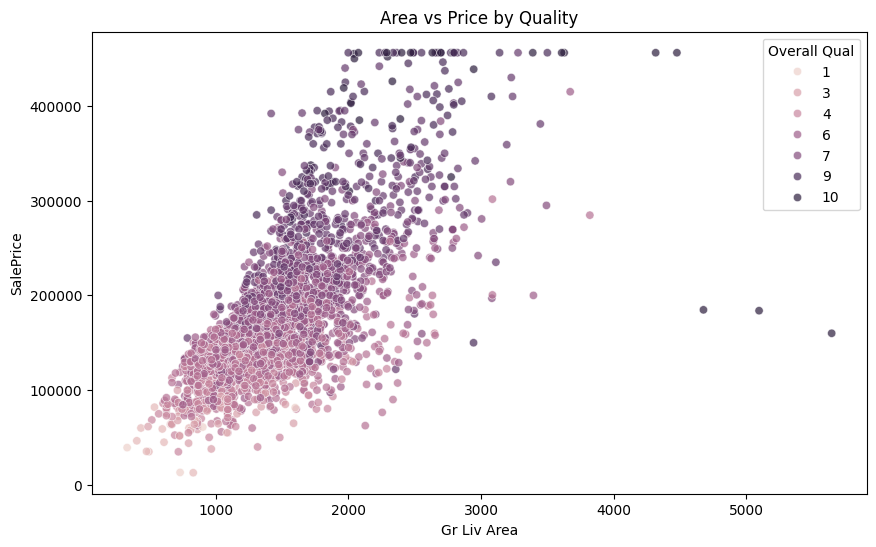

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Gr Liv Area', y='SalePrice', hue='Overall Qual', data=df, alpha=0.7)
plt.title('Area vs Price by Quality')
plt.show()

Insight: This scatter plot confirms that while size increases price, the quality level (represented by color) adds an additional layer of value for houses of the same size.

# (Groupby Summary)

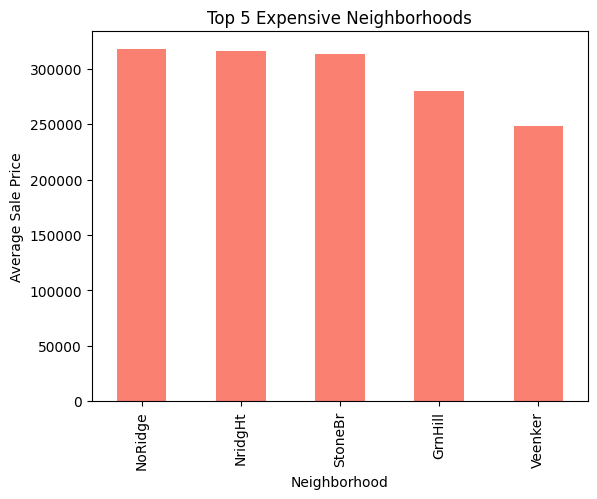

In [ ]:
summary = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)
summary.head(5).plot(kind='bar', color='salmon')
plt.title('Top 5 Expensive Neighborhoods')
plt.ylabel('Average Sale Price')
plt.show()

Insight: The neighborhood analysis shows that location is a key driver of price, with certain areas showing much higher average sale values than others.